In [47]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [42]:
class NPRTransform:
  def __call__(self, img):
    
    img_np = np.array(img).astype(np.float32)
    
    h, w = img_np.shape[:2]
    
    half = np.array(img.resize((w // 2, h // 2), Image.NEAREST))
    
    half_up = np.array(
      Image.fromarray(half).resize((w, h), Image.NEAREST)
    ).astype(np.float32)
    
    npr = img_np - half_up

    npr = npr - npr.min()
    npr = npr / (npr.max() + 1e-8) * 255
    npr = Image.fromarray(npr.astype(np.uint8))
    
    return npr  

In [43]:
transform = transforms.Compose([
  transforms.Resize((224, 224)),
  NPRTransform(),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [44]:
train_dataset = ImageFolder(
  root = "images/train",
  transform = transform
)

print("Number of images:", len(train_dataset))
print("Classes:", train_dataset.classes)
print("Class to label mapping:", train_dataset.class_to_idx)

Number of images: 19
Classes: ['fake', 'real']
Class to label mapping: {'fake': 0, 'real': 1}


In [45]:
train_loader = DataLoader(
  train_dataset,
  batch_size = 4,
  shuffle = True
)

print("Number of batches:", len(train_loader))

Number of batches: 5


In [46]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels:", labels)

Batch image shape: torch.Size([4, 3, 224, 224])
Batch labels: tensor([1, 1, 0, 0])


# NPR transform visualization

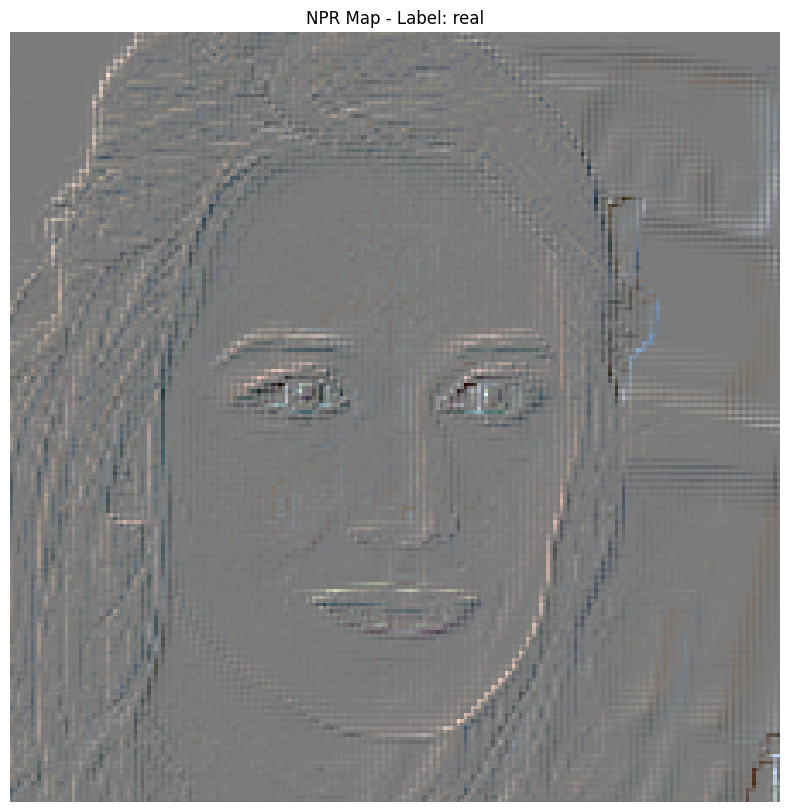

In [62]:
idx = 0
img = images[idx]
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_display = img * std + mean
img_display = img_display.clamp(0, 1)

img_display = img_display.permute(1, 2, 0).numpy()

plt.figure(figsize = (10, 10))
plt.imshow(img_display)
plt.title(f"NPR Map - Label: {'real' if labels[idx] == 1 else 'fake'}")
plt.axis('off')
plt.show()